
**CLIP
and BLIP📎**

Let's start by installing the necessary dependencies in our Colab notebook:

In [ ]:
!pip install torch torchvision ftfy regex tqdm transformers diffusers
!pip install git+https://github.com/openai/CLIP.git
!pip install git+https://github.com/salesforce/BLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

Let's use a Hugging Face model to generate an image from a prompt. We'll use the Stable Diffusion model:

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


scheduler%2Fscheduler_config.json:   0%|          | 0.00/345 [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/537 [00:00<?, ?B/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.46G [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

vae%2Fconfig.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

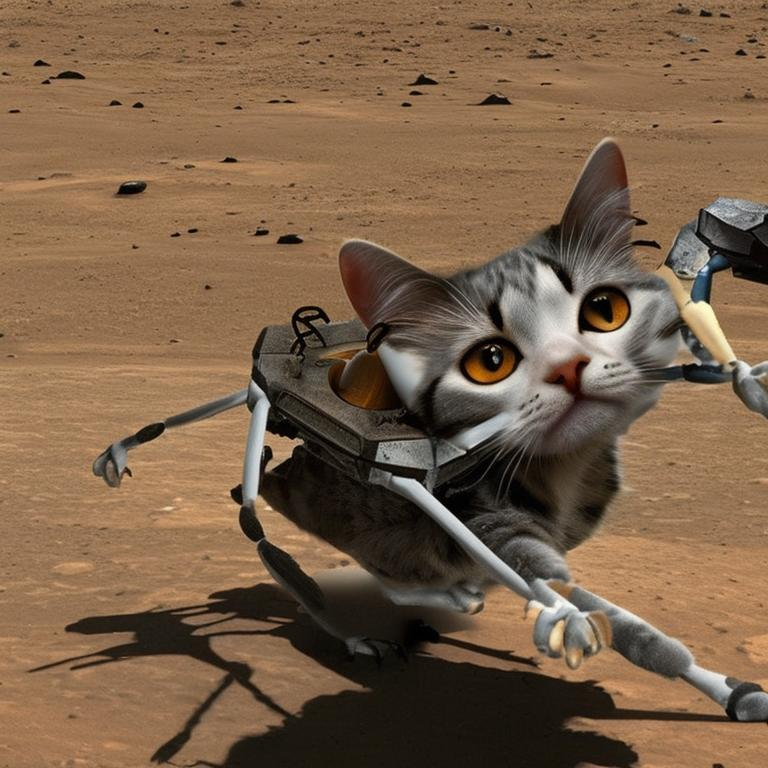

In [ ]:
import torch
from diffusers import StableDiffusionPipeline, EulerDiscreteScheduler

# Load the model
model_id = "stabilityai/stable-diffusion-2"
scheduler = EulerDiscreteScheduler.from_pretrained(model_id, subfolder="scheduler")
pipe = StableDiffusionPipeline.from_pretrained(model_id, scheduler=scheduler, torch_dtype=torch.float16)
pipe = pipe.to("cuda")

# Generate an image from a prompt
prompt = "a photo of a cat riding a crab on mars"
image = pipe(prompt).images[0]
image.save("generated_image.jpg")

# Display the image
from IPython.display import Image as IPImage
IPImage("generated_image.jpg")

Cute 🫠

**CLIP (Contrastive Language-Image Pre-Training)** is a neural network developed by OpenAI that's** trained on a variety of (image, text) pairs.**

CLIP's power lies in **its zero-shot capabilities,** similar to GPT models, allowing it to perform image classification tasks without being explicitly trained on labeled examples.

The key features of CLIP include:

**Joint training on images and text**

Zero-shot transfer to downstream tasks

**Ability to match images to textual descriptions**



Let's use CLIP to see how well it matches our generated image with different text descriptions:

In [ ]:
import clip
from PIL import Image

import torch

# Load CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# Load our generated image
image = Image.open("generated_image.jpg")
image_input = preprocess(image).unsqueeze(0).to(device)

# Create text descriptions to test
text_descriptions = [
    "a photo of an astronaut riding a horse on mars",
    "a photo of a cat riding a crab on mars",
    "a digital painting of a space explorer",
    "a photo of a person swimming"
]
text_tokens = clip.tokenize(text_descriptions).to(device)

# Calculate features
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_tokens)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

# Print results
for i, description in enumerate(text_descriptions):
    print(f"{description}: {similarity[0][i].item():.2%}")

a photo of an astronaut riding a horse on mars: 0.36%
a photo of a cat riding a crab on mars: 99.61%
a digital painting of a space explorer: 0.02%
a photo of a person swimming: 0.00%


**BLIP (Bootstrapping Language-Image Pre-training)** is a unified vision-language model developed by Salesforce that excels in both **understanding and generation tasks**

Pre-trained with three objectives: **image-text contrastive learning, image-text matching, and image-conditioned language modeling**

**Main Use Cases**:

**Image captioning**  - generating detailed descriptions of images

**Visual Question Answering (VQA)** - answering questions about visual content

**Image-text retrieval** - finding relevant images for text and vice versa

**Visual reasoning** - interpreting complex visual scenes

**Visual dialog** - conversational interaction about images

Zero-shot capabilities for video understanding

BLIP for Visual Question Answering

In [ ]:
from transformers import BlipProcessor, BlipForQuestionAnswering

# Load BLIP model for VQA
processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base").to(device)

# Load our generated image
image = Image.open("generated_image.jpg")

# Ask questions about the image
questions = [
    "Does this image have any animal if yes what",
    "Where is this scene taking place?",
    "Which animal is seen in the image"
]

for question in questions:
    inputs = processor(image, question, return_tensors="pt").to(device)
    out = model.generate(**inputs)
    print(f"Q: {question}")
    print(f"A: {processor.decode(out[0], skip_special_tokens=True)}")
    print()


Q: Does this image have any animal if yes what
A: yes

Q: Where is this scene taking place?
A: desert

Q: Which animal is seen in the image
A: cat

